# Fouille de processus

## Case study

#### Avec Aaron, Julien, Léo, Valentin et Zakaria

### About the log:

##### Traces analysis

#### Dependencies

In [10]:
import os
import pm4py
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Function to load XES files from a directory
def load_xes_files(directory):
    xes_files = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith('.xes')]
    return xes_files

directory = 'datasets'
xes_files = load_xes_files(directory)
event_logs = [pm4py.read_xes(file) for file in xes_files]

c:\Users\valmo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 10000/10000 [00:03<00:00, 2647.87it/s]


### Sampling the log
**Process discovery ($\alpha$-Algorythm)**

Petri net discovered for file renting_log_high.xes


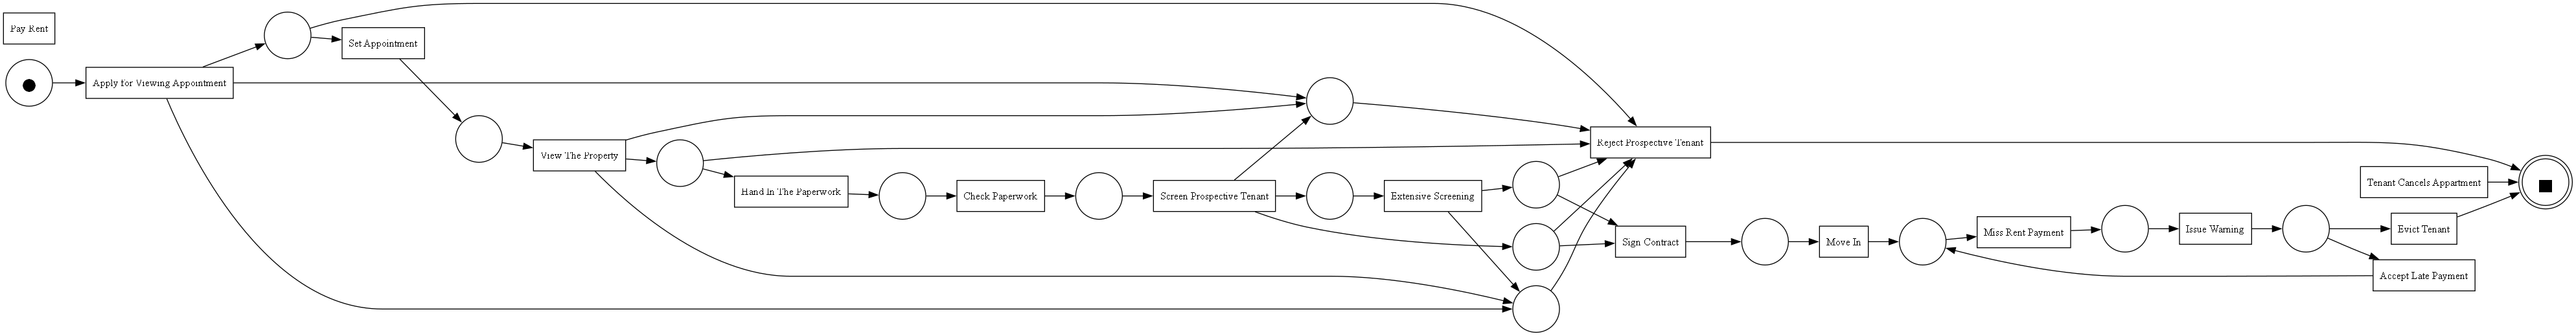

Petri net discovered for file renting_log_low.xes


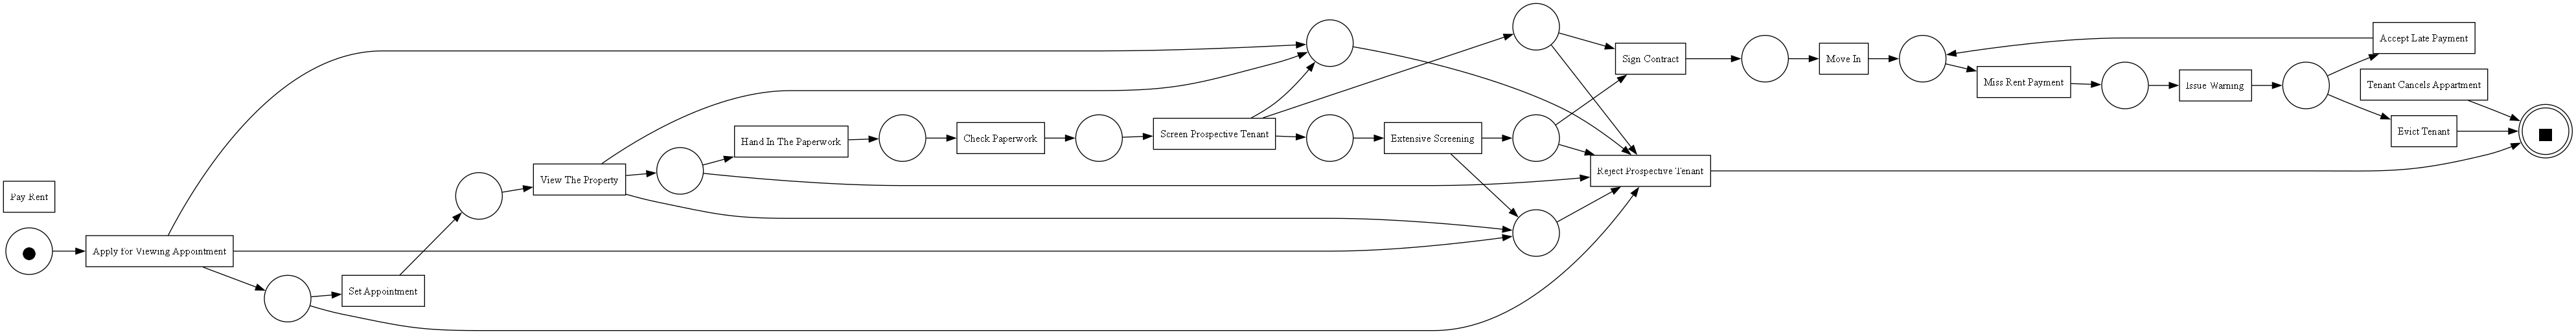

Petri net discovered for file renting_log_medium.xes


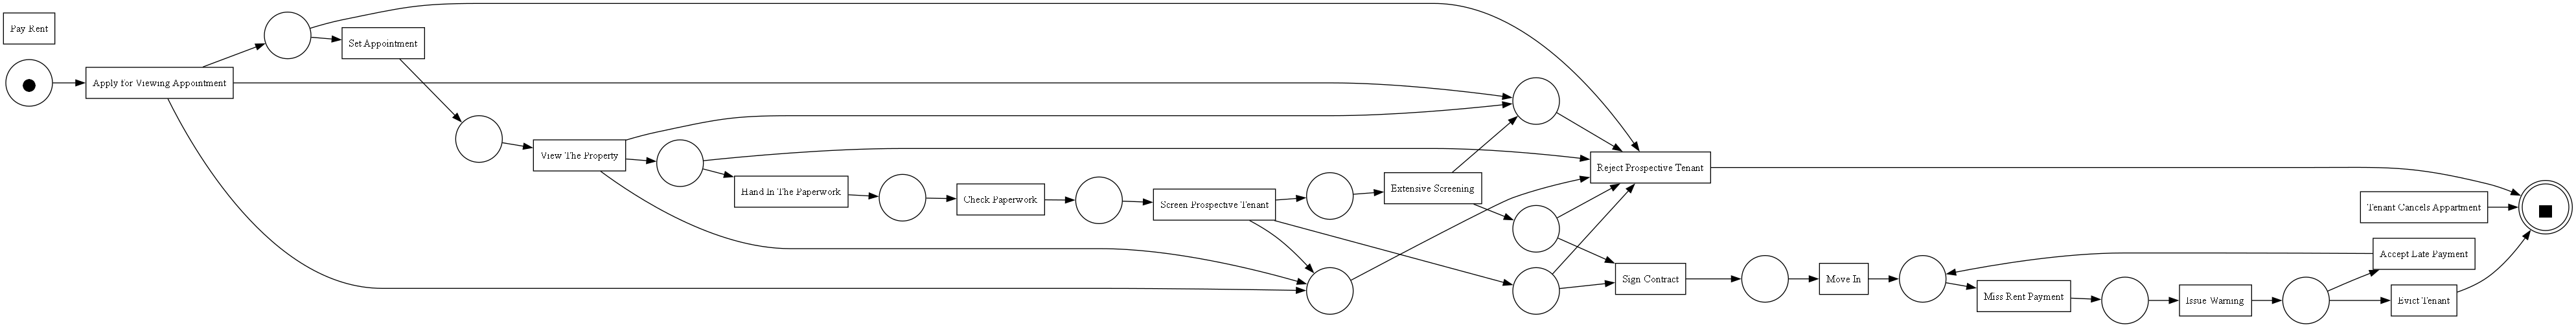

In [ ]:
models = []

#trying the alpha algorithm
for index, event_log in enumerate(event_logs): 
    file_name = xes_files[index].split("\\")[-1]
    net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(event_log)
    models.append({file_name + " (Petri from alpha miner)" : {"net": net, "initial_marking" : initial_marking, "final_marking" : final_marking}})
    print("Petri net discovered for file", file_name)
    pm4py.view_petri_net(net, initial_marking, final_marking)

### Visualize discriminant metrics
We'll visualize the difference between mutiple variables to see when a trace achieves the event "Sign Contract".

Plot discriminant factors for renting_log_high.xes


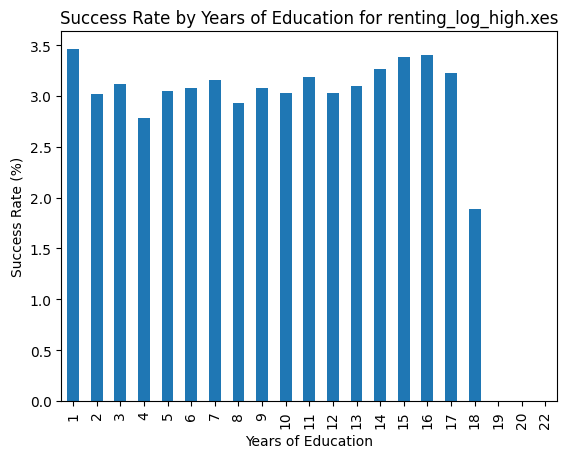

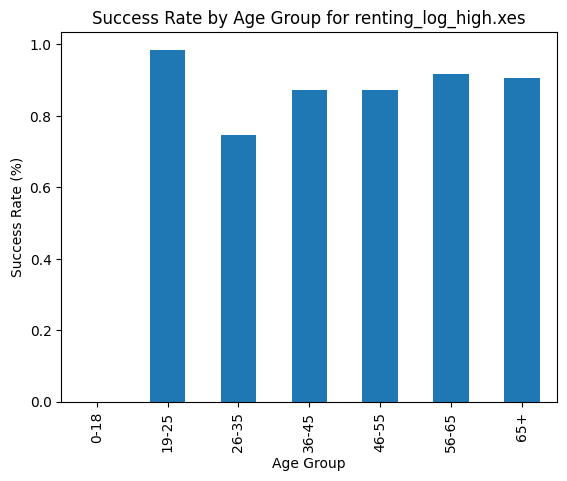

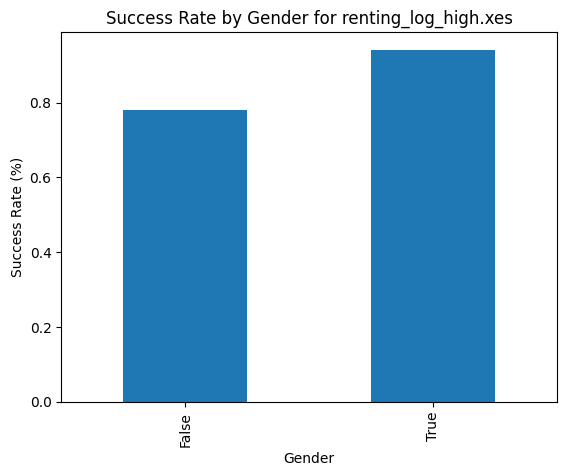

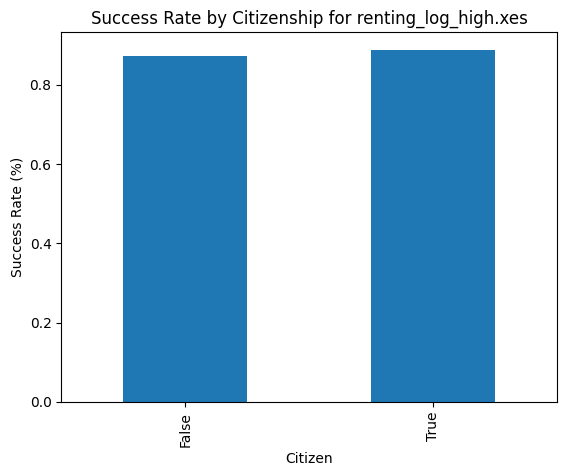

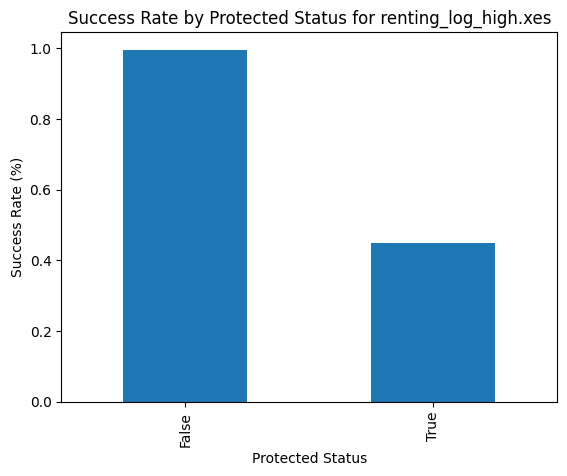

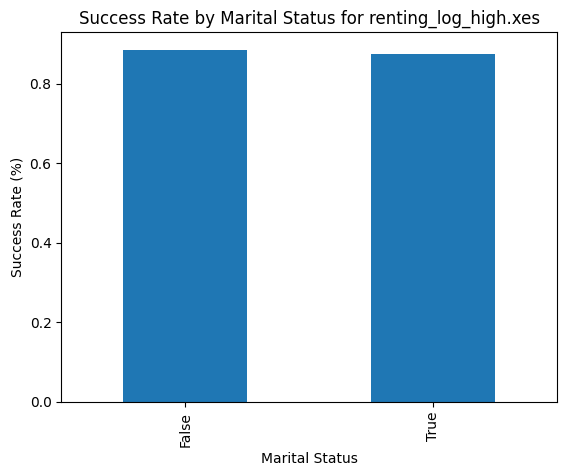

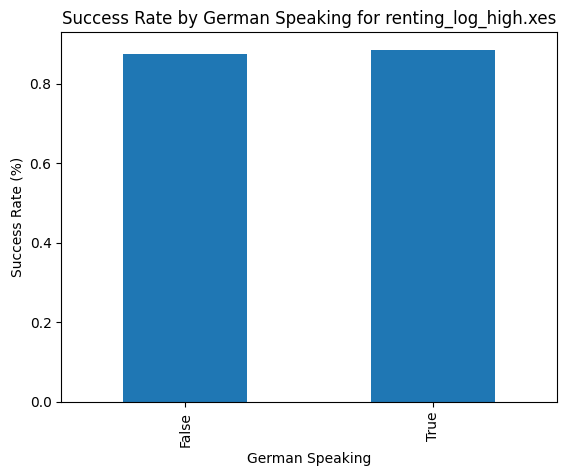

-------------------------
Plot discriminant factors for renting_log_low.xes


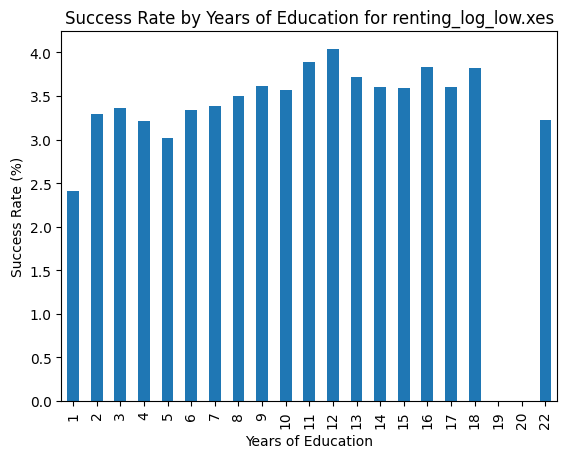

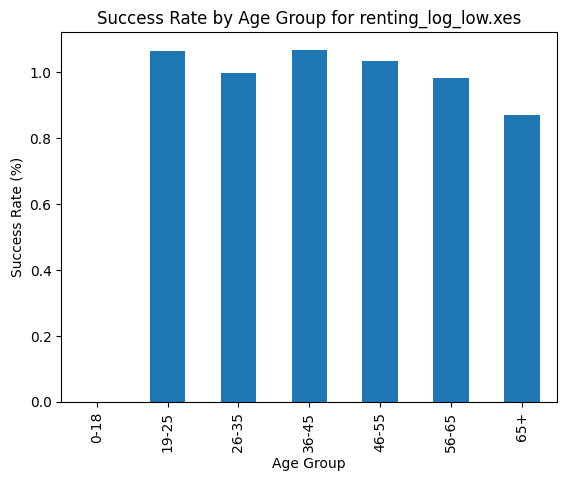

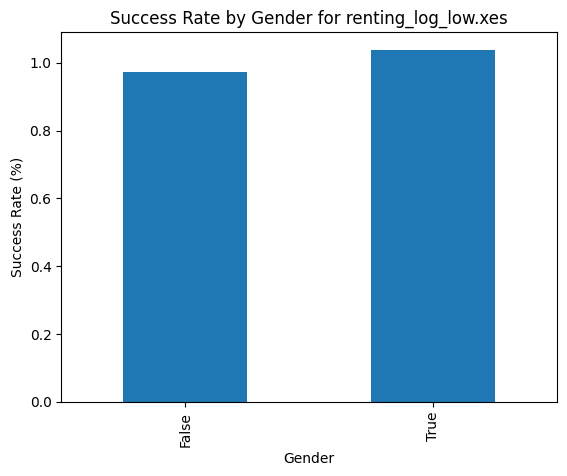

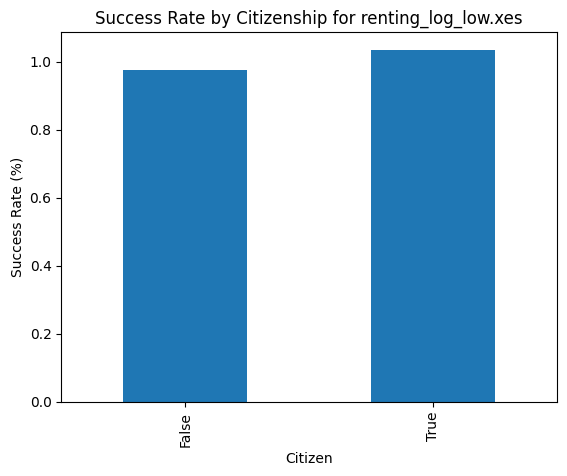

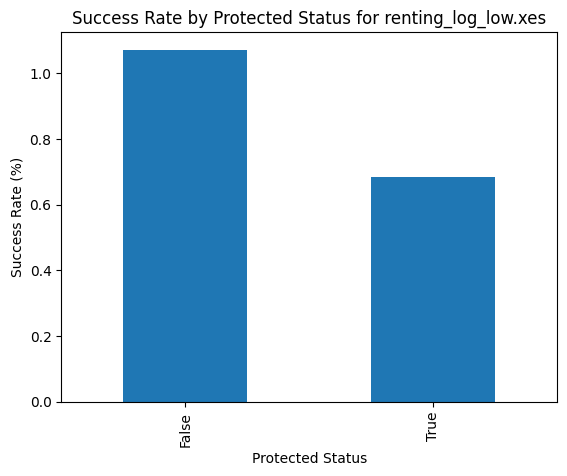

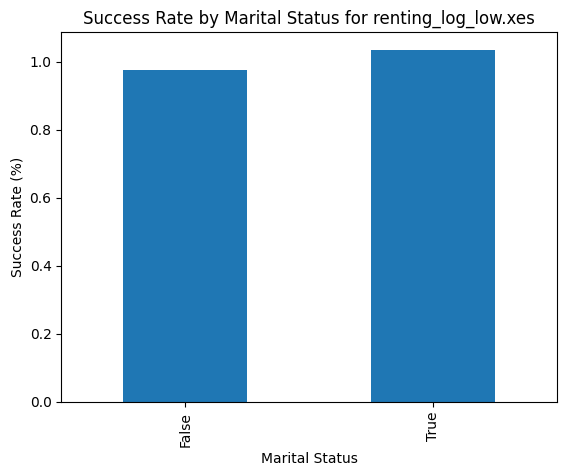

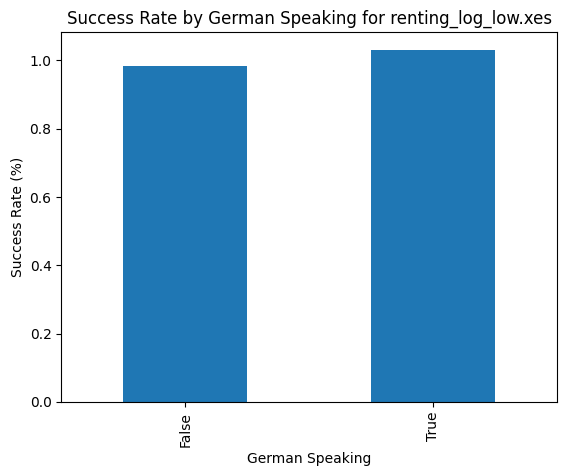

-------------------------
Plot discriminant factors for renting_log_medium.xes


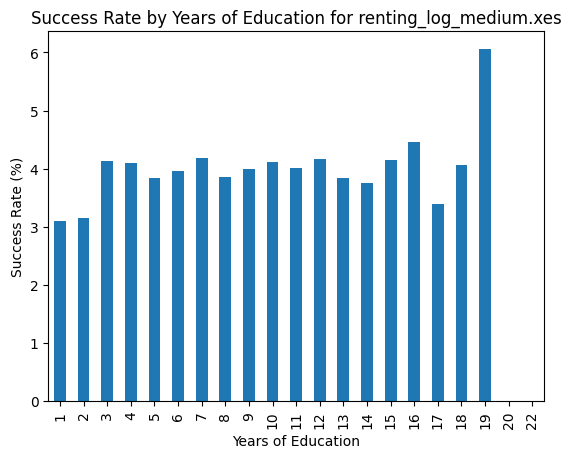

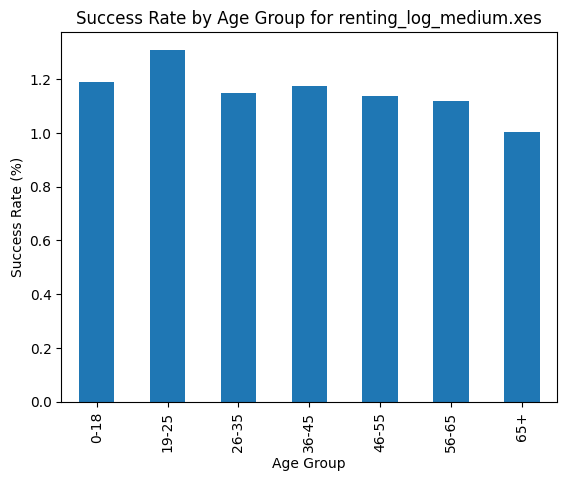

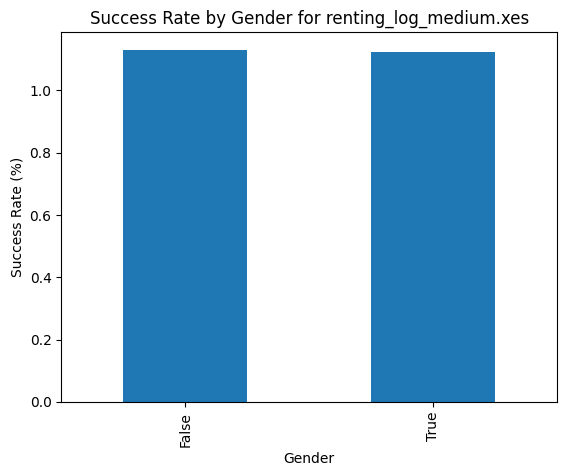

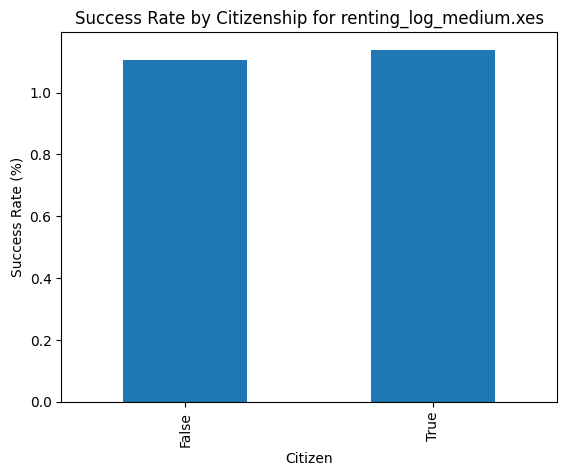

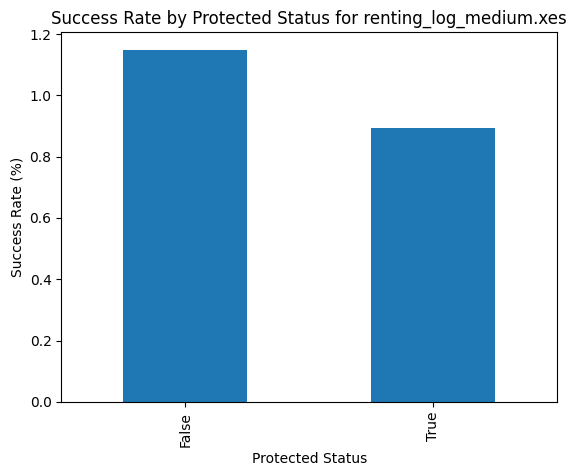

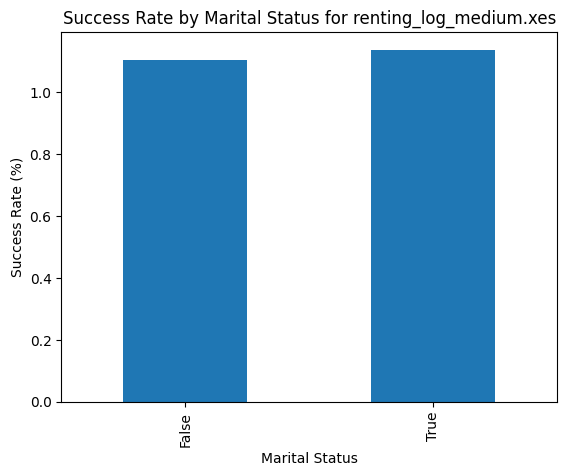

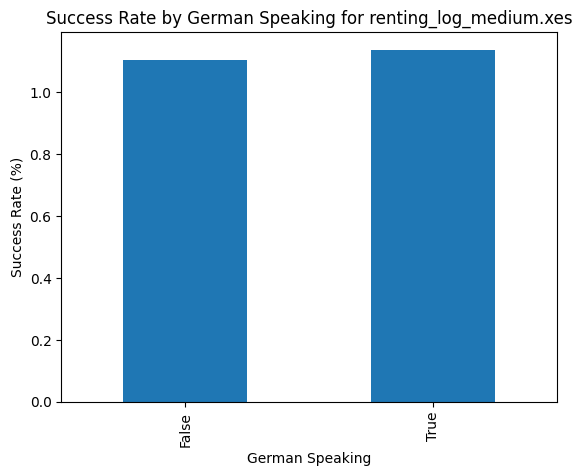

In [ ]:
def plot_discriminant_factors(df, log_name):
    # Extract relevant columns for analysis
    df_discriminant = df[['case:yearsOfEducation', 'case:age', 'case:gender', 'case:citizen', 'case:protected', 'case:married', 'case:german speaking', 'activity']]
    
    # Add a 'Success' column based on the 'Sign Contract' activity
    df_discriminant = df_discriminant.copy()
    df_discriminant['Success'] = df_discriminant['activity'].apply(lambda x: 1 if x == 'Sign Contract' else 0)
    
    # Create age bins
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']
    df_discriminant['age_group'] = pd.cut(df_discriminant['case:age'], bins=bins, labels=labels, right=False)
    
    # Plot success rate by years of education
    education_success = df_discriminant.groupby('case:yearsOfEducation')['Success'].mean() * 100 / 3.5
    education_success.plot(kind='bar', title=f'Success Rate by Years of Education for {log_name}')
    plt.xlabel('Years of Education')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by age group
    age_success = df_discriminant.groupby('age_group', observed=False)['Success'].mean() * 100 / 3.5
    age_success.plot(kind='bar', title=f'Success Rate by Age Group for {log_name}')
    plt.xlabel('Age Group')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by gender
    gender_success = df_discriminant.groupby('case:gender', observed=False)['Success'].mean() * 100 / 3.5
    gender_success.plot(kind='bar', title=f'Success Rate by Gender for {log_name}')
    plt.xlabel('Gender')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by citizenship
    citizen_success = df_discriminant.groupby('case:citizen', observed=False)['Success'].mean() * 100 / 3.5
    citizen_success.plot(kind='bar', title=f'Success Rate by Citizenship for {log_name}')
    plt.xlabel('Citizen')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by protected status
    protected_success = df_discriminant.groupby('case:protected', observed=False)['Success'].mean() * 100 / 3.5
    protected_success.plot(kind='bar', title=f'Success Rate by Protected Status for {log_name}')
    plt.xlabel('Protected Status')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by marital status
    married_success = df_discriminant.groupby('case:married', observed=False)['Success'].mean() * 100 / 3.5
    married_success.plot(kind='bar', title=f'Success Rate by Marital Status for {log_name}')
    plt.xlabel('Marital Status')
    plt.ylabel('Success Rate (%)')
    plt.show()
    
    # Plot success rate by german speaking
    german_speaking_success = df_discriminant.groupby('case:german speaking', observed=False)['Success'].mean() * 100 / 3.5
    german_speaking_success.plot(kind='bar', title=f'Success Rate by German Speaking for {log_name}')
    plt.xlabel('German Speaking')
    plt.ylabel('Success Rate (%)')
    plt.show()

for index, event_log in enumerate(event_logs):
    log_name = xes_files[index].split("\\")[-1]
    print("Plot discriminant factors for", log_name)
    plot_discriminant_factors(event_log, log_name)
    if index != len(event_logs) - 1:
        print("-"*25)


## Evaluate models

To evaluate a model, we need 4 metrics :
<center>
Fitness, Precision, Generaliszation and Simplicity
</center>

In [14]:
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

def model_evaluator(event_log, net, initial_marking, final_marking):
    evaluation = {}
    fitness = pm4py.fitness_token_based_replay(event_log, net, initial_marking, final_marking)
    evaluation['fitness'] = fitness
    prec = pm4py.precision_token_based_replay(event_log, net, initial_marking, final_marking)
    evaluation['precision'] = prec
    gen = generalization_evaluator.apply(event_log, net, initial_marking, final_marking)
    evaluation['generalization'] = gen
    simp = simplicity_evaluator.apply(net)
    evaluation['simplicity'] = simp
    return evaluation

for index, model in enumerate(models):
    log_name = list(model.keys())[0]
    net = list(model.values())[0]['net']
    initial_marking = list(model.values())[0]['initial_marking']
    final_marking = list(model.values())[0]['final_marking']
    event_log = event_logs[index]
    print("Evaluating model for", log_name)
    evaluation = model_evaluator(event_log, net, initial_marking, final_marking)
    print("Fitness:", evaluation['fitness'])
    print("Precision:", evaluation['precision'])
    print("Generalization:", evaluation['generalization'])
    print("Simplicity:", evaluation['simplicity'])
    if index != len(models) - 1:
        print("-"*25)

Evaluating model for (Petri from alpha miner)renting_log_high.xes


replaying log with TBR, completed traces :: 100%|██████████| 496/496 [00:00<00:00, 1368.84it/s]


Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.7663591440362545, 'log_fitness': 0.7577831470093864, 'percentage_of_fitting_traces': 0.0}
Precision: 0.36027325985157066
Generalization: 0.9771404952380432
Simplicity: 0.6153846153846154
-------------------------
Evaluating model for (Petri from alpha miner)renting_log_low.xes


replaying log with TBR, completed traces :: 100%|██████████| 508/508 [00:00<00:00, 1481.01it/s]


Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.7645500828761987, 'log_fitness': 0.756450414094077, 'percentage_of_fitting_traces': 0.0}
Precision: 0.36130451391884066
Generalization: 0.9791394702792057
Simplicity: 0.6153846153846154
-------------------------
Evaluating model for (Petri from alpha miner)renting_log_medium.xes


replaying log with TBR, completed traces :: 100%|██████████| 610/610 [00:00<00:00, 1484.72it/s]

Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.7645333283692183, 'log_fitness': 0.7572269639156843, 'percentage_of_fitting_traces': 0.0}
Precision: 0.3648994466806551
Generalization: 0.9814208798428365
Simplicity: 0.6153846153846154
